# Public Health Informatics (part 2)
## Asthma quality measures
In the **Public Health Informatics (part 1)** module, I introduced a number of important concepts for working with data. These concepts included **loading data**, **cleaning data**, and **visualizing data**.

This module expands on these concepts by defining functions to encapsulate many of operations. The are a number of reasons for wanting define such functions:
* Reduce repetition or copying/pasting of code. High repetition of code can make it more difficult to comprehend and increases the possibilty of making mistakes.
* It makes your code easier to reuse. If develop an analyis or visualization method that you find really handy, you can reuse it by simply calling the function.
* It makes your results more reproducable. If you share your functions with another researcher, that person use them to compare results across differnt datasets. 
* Instead of using a number of ad hoc operations on your data, you can (over time) build up a core set of funcitons to analyze similar datasets.

Similar to before, we will start by loading the libraries we want to work with.

In [1]:
## libaries for working with data
import pandas as pds
import numpy as np

## libraries for visualizations
import matplotlib.pyplot as plt
import altair as alt
alt.renderers.enable('notebook')

RendererRegistry.enable('notebook')

## Loading and cleaning data
Previously, we loaded and cleaned the asthma data in a number of steps:
1. Load the Excel file: `pds.ExcelFile("quality_measures_data.xlsx")`
2. Parse the Excel sheet: `qm_file.parse("Asthma")`
3. Clean up the column names: `df.columns.str.strip()` 
4. Replace `NaN` with `0`: `df.fillna(0)`
5. Replace missing `Provider ID`s with `"No ID"`: `df['Provider ID'].map(lambda x: x if x != 0 else 'No ID')`
6. Subset data to the fourth quarter: `df[df.Quarter == 'Q2 2018']`

However, the Excel file contains a number of sheets: BMI, CAD, COPD, etc.

If we wanted to compare data across these sheets, it would be tedious to redo the loading and cleaning operations for each sheet. This is good use case for a function.

## Define the function with docstrings
To encapsulate loading and cleaning data, let's define the function `make_quality_measure_dataframes` with parameters for the Excel file, sheet and quarter.
```python
def make_quality_measure_dataframes(excel_file, sheet_name, quarter)
```
In addtion to defining the function, it is also useful to provide a description what the funciton does, the parameters, and what the function returns.

This information is can be provided by defining a docstring after defining the function. A docstring is constructed using triplequotes (i.e., `"""`) on the line following the funciton definition. Here are some links with examples: 

https://www.pythonforbeginners.com/basics/python-docstrings
https://www.datacamp.com/community/tutorials/docstrings-python

Although there is no standard for this, I like to put information about paramerters and return types in separate sections of the doctstring, e.g.:
```
Args:
    param1: info about parameter 1
    param2: info about paramater 2
Returns:
    info aobut what it returns
```

With this in mind, let's define our `make_quality_measure_dataframes` fundction as follows:
```python
def make_quality_measure_dataframes(excel_file, sheet_name, quarter):
    """Builds pandas dataframes from an Excel file.
    
    Args:
        excel_file: the name of Excel file holding data
        sheet_name: the name of the sheet in the Excel file holding data
        quarter: the name of the quarter used to subset data
    Returns:
        df: dataframe of all the data in the Excel file sheet
        df_quarter: dataframe a subset of data in df based on quarter parameter
        df_fillna: dataframe in which NaN values from df_quarter are filled with 0
    """
```

We could have (of course) provided the information in the docstring using commments (i.e., `#`). But a nice feature of docstrings is you can now use Python's `help` funciton to retrieve the docstring information. Execute the code cell below for an example of this.

In [2]:
def make_quality_measure_dataframes(excel_file, sheet_name, quarter):
    """Builds pandas dataframes from an Excel file.
    
    Args:
        excel_file: the name of Excel file holding data
        sheet_name: the name of the sheet in the Excel file holding data
        quarter: the name of the quarter used to subset data
    Returns:
        df: dataframe of all the data in the Excel file sheet
        df_quarter: dataframe a subset of data in df based on quarter parameter
        df_fillna: dataframe in which NaN values from df_quarter are filled with 0
    """

help(make_quality_measure_dataframes)

Help on function make_quality_measure_dataframes in module __main__:

make_quality_measure_dataframes(excel_file, sheet_name, quarter)
    Builds pandas dataframes from an Excel file.
    
    Args:
        excel_file: the name of Excel file holding data
        sheet_name: the name of the sheet in the Excel file holding data
        quarter: the name of the quarter used to subset data
    Returns:
        df: dataframe of all the data in the Excel file sheet
        df_quarter: dataframe a subset of data in df based on quarter parameter
        df_fillna: dataframe in which NaN values from df_quarter are filled with 0



## Multiple return variables
A nice feature of Python is that allows to easily return multiple variables. If you read the docstring for `make_quality_measure_dataframes`, you see that specify that function returns three dataframs: `df`, `df_quarter`, and `df_fillna`. The names of these data frames correspond to names we used in the **Asthma quality measures (part 1)** module. We could have given the variables any name we wanted.

As an example of returning multiple variables, let's create a simple function that returns two words: `"Hello"` and `"World"`.
```python
def hello_world():
    word1 = "Hello"
    word2 = "World"
    return word1, word2
```
When we call this function, we simply assign the result to two variables:
```python
x, y = hello_world()
```
Now we can print `x` and `y`:
```python
print(x, y)
```
which produces our expected output:
```python
Hello World
```

We are now ready to implement our `make_quality_measure_dataframes` function. In our code cell below, I have implement to steps needed to load a dataframe from an Excel file, subset the data to a give quarter, and clean the replace missing values. The steps mirror the operations we did in distinct cells in the **Asthma quality measures (part 1)** module. Take some time and look back at that module to understand how the dataframs are being created.

In [3]:
def make_quality_measure_dataframes(excel_file, sheet_name, quarter):
    """Builds pandas dataframes from an Excel file.
    
    Args:
        excel_file: the name of Excel file holding data
        sheet_name: the name of the sheet in the Excel file holding data
        quarter: the name of the quarter used to subset data
    Returns:
        df: dataframe of all the data in the Excel file sheet
        df_quarter: dataframe a subset of data in df based on quarter parameter
        df_fillna: dataframe in which NaN values from df_quarter are filled with 0
    """
    # read Excel file and parse sheet
    df = pds.ExcelFile(excel_file).parse(sheet_name)

    ## column names may have leading/trailing spaces
    ## so do some cleanup to make working with columns easier to work with


    cleaned_columns = df.columns.str.strip()

    ## more complex cleaning process; not used for this project
    # cleaned_columns = \
    # 	df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('(', '').str.replace(')', '')

    df.columns = cleaned_columns

    ## get data for quarter
    df_quarter = df[quarter == df.Quarter]

    ## replace NaN with 0 and replace null provider ids with 'No ID'
    df_fillna = df_quarter.fillna(0)
    df_fillna['Provider ID'] = df_fillna['Provider ID'].map(lambda x: x if x != 0 else 'No ID')

    return df, df_quarter, df_fillna


In [4]:
## we can now simple create our dataframes in simple call to the function
df, df_quarter, df_fillna = make_quality_measure_dataframes("quality_measures_data.xlsx", "Asthma", "Q2 2018")

In [5]:
## uncomment the lines below to verify the data was loaded
# df.head()
# df_quarter
# df_fillna


## Grouping funcitons
Before we start visualizing data, it is helpful (as before) to create dataframes with the totals and percentages. For this we will define a function names `make_quality_measures_groups` with parameters:
* `df`: the dataframe used to calculate the group totals and percents
* `data_cols`: a list of the columns that holds data need to calculate totals and percentages
* `patient_col`: the column in the dataframe that holds the number of patients seen by the provider
* `index_col`: the column that holds the value used to identify a group/row (default group_id)

We will return two dataframes:
* `group_totals`: a dataframe with totals (i.e., summed values) of quality measures
* `group_pct`: a dataframe with percentages (i.e.: ration of measure/number of patients) of quality measures


## Calculating totals
Our function will return a `group_totals` dataframe. This process is straightforward. As before, we will use Pandas `pivot_table` function to aggregate the totals:
```python
group_totals = \
        pds.pivot_table(df, values=data_cols, index=[index_col], aggfunc=np.sum)
```

## Calculating percentage
If you recall from the **Asthma quality measures (part 1)** module, we needed to both calculate the ratio and convert it to a percet (e.g., 0.10 -> 10%). To do this, we will define an inner function. An inner function is a function that is defined inside of another function. These come in handy when you need to encapsulate code within your function, but are not concerned with having that function globally accessible (i.e., allowing the funciton to be called by any other function). When you define an inner function, this limits the scope of the function so that it can only be called from withing that funciton.

For example, here is a function `f1` that has inner function `f2`:
```python
def f1():
    def f2(x):
        return x * x # multply x by itself
    
    list_1 = []
    for i in range(5): # iterate over integers 0-4
        list_1.append(f2(i))
        
    return list_1 # returns the list [0, 1, 4, 9, 16]
```
Calling `f1()` returns:
```python
[0, 1, 4, 9, 16]
```
but calling `f2()` returns an <span style="color:red">error</span>:
```python
NameError: name 'f2' is not defined
```

To calculate the percentage we need two pieces of information:
1. The numerator: this we will define as the total number of patients that received a measurement
2. The denominator: this define as the total number of patients seen

The percentage is then calculated using mathematical operations:
```python
## inner function used to calculate percentage
def calc_percent(measure_num, patient_num):
    if patient_num <= 0:
        return 0
    else:
        return round((measure_num / patient_num) * 100, 2)
```

With this inner function defined, we can now iterate over the data columns in `group_totals` dataframe and calculate the percentage for each column:
```python
## calculate percentages
for col in data_cols:
    if col != patient_col:
        group_pct[col] = group_totals.apply(lambda row: calc_percent(row[col], row[patient_col]), axis=1)
```

Below is my implementation of `make_quality_measures_groups` function. There are two import things to note. First, I make a copy of the `group_totals` datafame using `group_totals.copy()`. Using the `copy` method creates a new copy of the values in the new dataframe instead of only copying the references. Information about Pandas `copy` is found here: https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.copy.html

Second, I use `axis=1` when calling the `apply` method. This tells Pandas to operate on the data by rows (or indexes) intead of columns, and is needed in order to access the values in the `row[col]` and `row[patient_col]` cells. See here for further information: https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.apply.html

In [6]:
def make_quality_measures_groups(df, data_cols, patient_col, index_col='Group ID'):
    """Builds pandas dataframes that group totals and percentages

    Args:
        df: the dataframe used to calculate the group totals and percents
        data_cols: a list of the columns that holds data need to calculate totals and percentages
        patient_col: the column in the dataframe that holds the number of patients seen by the provider
        index_col: the column that holds the value used to identify a group/row (default group_id)
    Returns:
        group_totals: a dataframe with totals (i.e., summed values) of quality measures
        group_pct: a dataframe with percentages (i.e.: ration of measure/number of patients) of quality measures
    """

    ## inner function used to calculate percentage
    def calc_percent(measure_num, patient_num):
        if patient_num <= 0:
            return 0
        else:
            return round((measure_num / patient_num) * 100, 2)

    ## sum up the totals in the data columns
    group_totals = \
        pds.pivot_table(df, values=data_cols, index=[index_col], aggfunc=np.sum)

    ## create dataframe for percentages
    group_pct = group_totals.copy()  # create copy of totals

    ## calculate percentages
    for col in data_cols:
        if col != patient_col:
            group_pct[col] = group_totals.apply(lambda row: calc_percent(row[col], row[patient_col]), axis=1)

    return group_totals, group_pct


## Extracting data columns
In order to calculate the group totals and percentages of the data, we need to specify which columns hold the data. We could do this by simply defining a list with these names, e.g.:
```python
data_cols = ['Asthma Patients', 'Inhaler prescribed', 'Spiro 1 yr']
```
But, this would require that we do this for every sheet in the Excel file. 

A better way to determine the data columns is to create a function to do this. Below, I define a function named `extract_data_cols` and takes a datafame and returns the data columns.

The working logic is that since all the sheets have Quarter, Site ID, Group ID, and Provider ID columns that are **not** used in computing totals or percentages, I simply remove these columns and return the remaining columns.

Since (depending on the situation) we may or may not wish to remove the column containing the number of patients seen by the provider, I specify that the `patient_col` is optional by giving a default value of `""` (i.e., the empty string). However, if a column name is provided it is removed:
```python
if len(patient_col.strip()) > 0:
    data_cols.remove(patient_col)
```

In [7]:
def extract_data_cols(df, patient_col=""):
    """Extract names of columns that hold data of interest.
    
    Args:
        df: the dataframe from which the column names will be extracted
        patient_col: if provided, the name of column holding patient count data
    Returns:
        data_cols: a list of column names in df that hold data of of interest.
    """
    data_cols = list(df.columns)


    data_cols.remove('Quarter')
    data_cols.remove('Site ID')
    data_cols.remove('Group ID')
    data_cols.remove('Provider ID')

    if len(patient_col.strip()) > 0:
        data_cols.remove(patient_col)

    return data_cols

We are now ready to call our `make_quality_measures_groups` function. Execute the code cells below and uncomment the lines with the group dataframes to verify that output.

You press the `control/command` keys and `/` key quicky comment/uncomment a line.

In [8]:
data_cols = extract_data_cols(df_fillna)
group_totals, group_pct = make_quality_measures_groups(df_fillna, data_cols, 'Asthma Patients')

In [9]:
## uncomment the lines below to verify group totals and percentages
# group_totals
# group_pct

## Visualization functions
With the group totals and precentage functions define, we can now focus on creating functions for visualizing the data.

The advantage of doing this is that visualization functions often have many options. However, for your specific project, you can keep a many of these options constant and then pass specific paramters to adjust dimensions you may want to change (such the height, width, and titles).

Recall from the **Asthma quality measures (part 1)** module that we created a facet chart which included a bar chart showing the number of patients. Below is the code used to draw this chart, but I have wrapped the code in a function named `make_num_patients_bar_chart`. Now I can quickly draw a bar chart of the number of patient charts, and easily configure what height, width, and title I want. Since I many not want to specify the height, width, or title, I also provide default values.

In [10]:
def make_num_patients_bar_chart(data, patient_col, width=50, height=125, y_title="Number of patients"):
    """Builds an Altair bar chart of the number of patients per group.
    
    Args:
        data: the pandas dataframe used to make the chart
        patient_col: column in the dataframe that holds the number of patients
        width: the width in pixels of the chart (default 50)
        height: the height in pixels of the chart (default 125)
        y_title: the title of the y axis
    Returns:
        count_chart: a bar chart showing the number of patients per group
    """
    count_chart = alt.Chart(data) \
        .mark_bar() \
        .encode(
        tooltip=['Group ID', patient_col],
        x=alt.X('Group ID', title=None, axis=alt.Axis(labelAngle=0)),
        y=alt.Y(patient_col, title=y_title)) \
        .properties(width=width, height=height)

    return count_chart

Now, let's test work. In the code cells below, I build the `data` dataframe needed as input to the visualization function and call `make_num_patients_bar_chart` to draw the chart.

Uncomment and execute the code cells below to confirm the output.

In [11]:
## use melt to transform the group_pct dataframe into from needed by make_num_patients_bar_chart
data = pds.melt(group_pct.reset_index(), 
                id_vars=['Group ID', 'Asthma Patients'], 
                var_name='Measure', value_name='Percent')

In [12]:
## call visualization function
# make_num_patients_bar_chart(data, "Asthma Patients")


With `make_num_patients_bar_chart` function now implemented, we can now create a visualization function for the facet chart. Let's name the function `make_measures_facet_bar_chart`. You have probably noticed by now that naming functions and variables is not a terribly creative endeavor. You want these names to be descriptive of what function does, and this often results in boring names :(

Similar to the numbers bar chart, `make_measures_facet_bar_chart` will need as input the data and the column with the patient counts. We will also provide default values for the height, width, and legend titles.

Since this function uses `make_num_patients_bar_chart`, I also provide the paramer `count_y_title` to set the title of the y-axis in patient number bar chart. And, in case you don't want to include the numbers bar chart, I provide a paramert named `include_count` (default `True`) to control whether the numbers bar chart is included as a facet.

Uncomment and execute the code cells below to view the output.

In [13]:
def make_measures_facet_bar_chart(data, patient_col, order_cols=[], width=50, height=125,
                                  include_count=True, legend_title="Measure", count_y_title="Number of patients"):
    """Builds an Altair facet bar chart of quality measures and (optionally)the number of patients per group.
    
    Args:
        data: the pandas dataframe used to make the chart
        patient_col: column in the dataframe that holds the number of patients seen by the group
    order_cols: a list of column names that spefices the order of the bar charts; if empty the program determines the order
        width: the width in pixels of the chart (default 50)
        height: the height in pixels of the chart (default 125)
        include_count: specifies whether to inlcude the bar chart of the number of patients per group (default True)
        legend_title: the title of the legend
        count_y_title: the title of the y axis of the chart showing the number of patients
    Returns:
        chart: faceted bar chart with each facet showing the percentage of a quality measure and (optionally)
        a bar chart facet showing the number of patients per group.
    """
    ## build facet bar chart with each facet having a quality measure
    measure_chart = \
        alt.Chart(data) \
            .mark_bar() \
            .encode(x=alt.X('Group ID', title=None, axis=alt.Axis(labelAngle=0)),
                    y=alt.Y('Percent'),
                    tooltip=['Measure', patient_col, 'Percent'],
                    color=alt.Color('Measure',
                                    sort=order_cols,
                                    legend=alt.Legend(title=legend_title),
                                    scale=alt.Scale(scheme='dark2'))) \
            .properties(width=width, height=height) \
            .facet(column=alt.Column('Measure', sort=order_cols, title=None))

    ## if include_count=True,build patient count chart and return concatenation of measures and count charts 
    ## otherwise, just return measures chart
    if include_count:
        count_chart = make_num_patients_bar_chart(data, patient_col, width, height, count_y_title)
        return \
            alt.hconcat(measure_chart, count_chart) \
                .configure_legend(orient="left", labelFontSize=12, titleFontSize=12) \
                .configure_header(labelLimit=1)
    else:
        return measure_chart \
            .configure_legend(orient="left", labelFontSize=12, titleFontSize=12) \
            .configure_header(labelLimit=1)


In [14]:
## call visualization function
## experiment with paramertes to see how you can control the output
# make_measures_facet_bar_chart(data, "Asthma Patients")


## Streamling the visualization process
Suppose we wanted to output a number visualizations from varous sheets in the Excel file. Calling the functions we've defined above may still seem a bit tedious. So, let's put all the steps into a single function.

Conceptually, we have done the following steps to get our visualization dataset:
1. create the cleaned dataframe (e.g., `df_fillna`)
2. create the grouped dataframes (e.g., `group_totals` and `group_pct`)
3. create the dataframe used as input to the visualization functions (e.g. `data`)

To streamline the creation of these dataframes, let's encapsulate these steps into a single function `make_visualization_dataframe`, defined below. Now we easily data from various sheets in the Excel file.

Uncomment and execute the code cells below to view the output.


In [15]:
def make_visualization_dataframe(excel_file, sheet_name, quarter, patient_col):
    """Builds pandas dataframes from Excel file for use in our quality measurement visualization methods.

    Args:
        excel_file: the name of Excel file holding data
        sheet_name: the name of the sheet in the Excel file holding data
        quarter: the name of the quarter used to subset data
    Returns:
        viz_data: dataframe that has been structures for use in the quality measurement visualizations
    """
    df, df_quarter, df_fillna = \
        make_quality_measure_dataframes(excel_file, sheet_name, quarter)

    data_cols = extract_data_cols(df_fillna)
    group_totals, group_pct = \
        make_quality_measures_groups(df_fillna, data_cols, patient_col)

    viz_data = pds.melt(group_pct.reset_index(),
                        id_vars=['Group ID', patient_col],
                        var_name='Measure', value_name='Percent')
    return viz_data

In [20]:
df_copd = make_visualization_dataframe("quality_measures_data.xlsx", "COPD", "Q2 2018", "COPD Patients")
df_well_visits = make_visualization_dataframe("quality_measures_data.xlsx", "Well Visits", "Q2 2018", "TotalPatients")


In [21]:
copd_bar_chart = make_measures_facet_bar_chart(df_copd, 'COPD Patients')
well_visits_bar_chart = make_measures_facet_bar_chart(df_well_visits, 'TotalPatients')


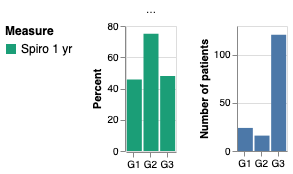

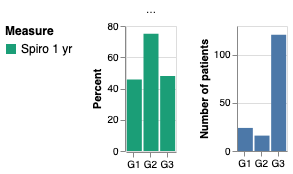

In [22]:
copd_bar_chart.display()

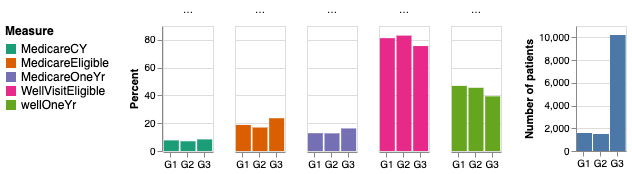

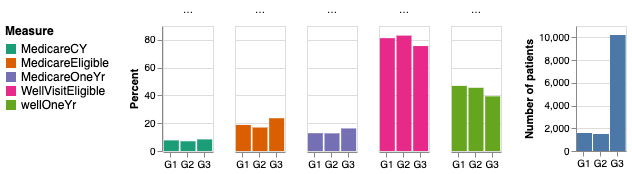

In [23]:
well_visits_bar_chart.display()

## Wrapping up
In this notebook, I have discussed a number of important concepts for defining functions that will make data exploriation tasks more reproducible, extensible, and sharable, such as:
* Returning multiple variables/values from your functions
* Writing docstrings
* Defining inner functions
* Defining default values for function parameters

We used to these concepts to implement functions to create necessary dataframes and display data visualizations. There is still a lot you can learn in this area, such as how to create your own libraries. Hopefully, this module has sparked your interest to delve further into these topics.